In [1]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules


In [2]:
# ==========================================
# 2. CARGA Y LIMPIEZA TOTAL DE DATOS
# ==========================================
ruta = 'all_games.csv'
df_final = pd.read_csv(ruta)


In [3]:
# Limpieza de nombres y eliminación de nulos
df_final['platform'] = df_final['platform'].str.strip()
df_final = df_final.dropna(subset=['meta_score'])

# Definición de la métrica de éxito (Meta Score > 85)
df_final['High_Quality'] = (df_final['meta_score'] > 85).astype(int)


In [4]:
# ==========================================
# 3. PREPARACIÓN DE MATRIZ (TRANSACCIONAL)
# ==========================================
# Creamos la matriz binaria
df_pivot = pd.get_dummies(df_final[['platform']], prefix='', prefix_sep='')


In [5]:
# UNIFICACIÓN: Aquí insertamos la columna con el nombre exacto
df_pivot['High_Quality'] = df_final['High_Quality'].values

# OBLIGATORIO: Convertir a Booleano para evitar errores de mlxtend
df_pivot = df_pivot.astype(bool)


In [6]:
# ==========================================
# 4. ENTRENAMIENTO (APRIORI)
# ==========================================
# Usamos un soporte bajo (0.1%) para garantizar que el modelo genere resultados
frequent_itemsets = apriori(df_pivot, min_support=0.001, use_colnames=True)


In [7]:
# Inicializamos la variable reglas para que siempre esté definida
reglas = pd.DataFrame()

if not frequent_itemsets.empty:
    # Generamos las reglas de asociación
    reglas = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
    
    # LIMPIEZA DE FROZENSETS: Evita el error de "Object of type frozenset"
    if not reglas.empty:
        reglas['antecedents'] = reglas['antecedents'].apply(lambda x: ', '.join(list(x)))
        reglas['consequents'] = reglas['consequents'].apply(lambda x: ', '.join(list(x)))


In [8]:
# ==========================================
# 5. MÉTODO DE PRUEBA 
# ==========================================
def consultar_asociacion(nombre_plataforma):
    if reglas.empty:
        print(f"\n[!] No se generaron reglas. Revisa los umbrales de soporte.")
        return

    nombre_plataforma = nombre_plataforma.strip()
    # Búsqueda segura en texto
    resultado = reglas[reglas['antecedents'].str.contains(nombre_plataforma, na=False)]
    
    if not resultado.empty:
        print(f"\n>>> Análisis de Asociación para: {nombre_plataforma}")
        for idx, row in resultado.iterrows():
            print(f"    - Si es de {nombre_plataforma} -> Entonces {row['consequents']}")
            print(f"      (Confianza: {row['confidence']:.2%}, Lift: {row['lift']:.2f})")
    else:
        print(f"\n[!] No se encontraron asociaciones fuertes para '{nombre_plataforma}'.")


--- TOP REGLAS ENCONTRADAS ---
    antecedents   consequents  confidence      lift
0     Dreamcast  High_Quality    0.208000  2.534284
1      GameCube  High_Quality    0.127232  1.550204
2   Nintendo 64  High_Quality    0.309859  3.775342
3  High_Quality            PC    0.267012  1.032038
4   PlayStation  High_Quality    0.272727  3.322925

[!] No se encontraron asociaciones fuertes para 'PC'.

>>> Análisis de Asociación para: Nintendo 64
    - Si es de Nintendo 64 -> Entonces High_Quality
      (Confianza: 30.99%, Lift: 3.78)


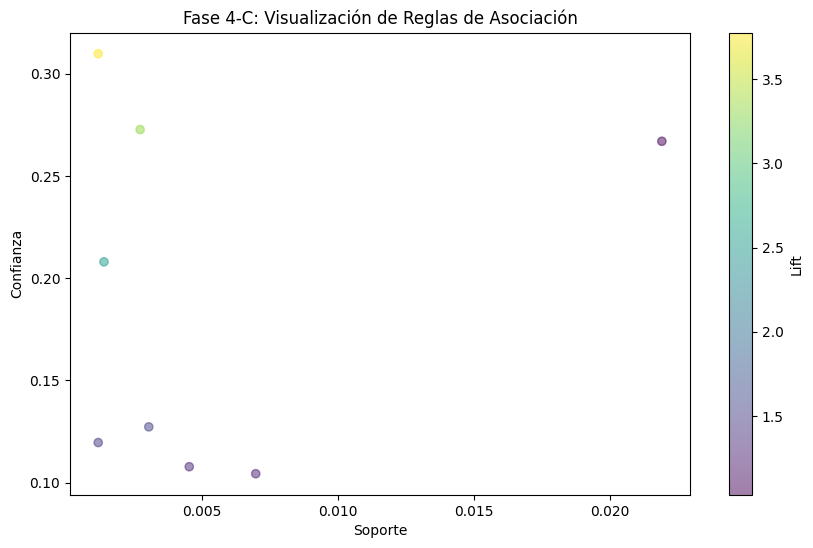

In [9]:
# ==========================================
# 6. EJECUCIÓN Y RESULTADOS
# ==========================================
if not reglas.empty:
    print("--- TOP REGLAS ENCONTRADAS ---")
    print(reglas[['antecedents', 'consequents', 'confidence', 'lift']].head())
    
    # Pruebas sugeridas
    consultar_asociacion('PC')
    consultar_asociacion('Nintendo 64')
    
    # Visualización
    plt.figure(figsize=(10, 6))
    plt.scatter(reglas['support'], reglas['confidence'], alpha=0.5, c=reglas['lift'], cmap='viridis')
    plt.colorbar(label='Lift')
    plt.title("Fase 4-C: Visualización de Reglas de Asociación")
    plt.xlabel("Soporte")
    plt.ylabel("Confianza")
    plt.show()
else:
    print("\n[!] EL MODELO NO GENERÓ REGLAS. Verifica que los datos se hayan cargado correctamente.")


--- TOP REGLAS ENCONTRADAS ---
    antecedents   consequents  confidence      lift
0     Dreamcast  High_Quality    0.208000  2.534284
1      GameCube  High_Quality    0.127232  1.550204
2   Nintendo 64  High_Quality    0.309859  3.775342
3  High_Quality            PC    0.267012  1.032038
4   PlayStation  High_Quality    0.272727  3.322925

>>> Análisis de Asociación para: GameCube
    - Si es de GameCube -> Entonces High_Quality
      (Confianza: 12.72%, Lift: 1.55)

>>> Análisis de Asociación para: PlayStation
    - Si es de PlayStation -> Entonces High_Quality
      (Confianza: 27.27%, Lift: 3.32)
    - Si es de PlayStation -> Entonces High_Quality
      (Confianza: 10.43%, Lift: 1.27)


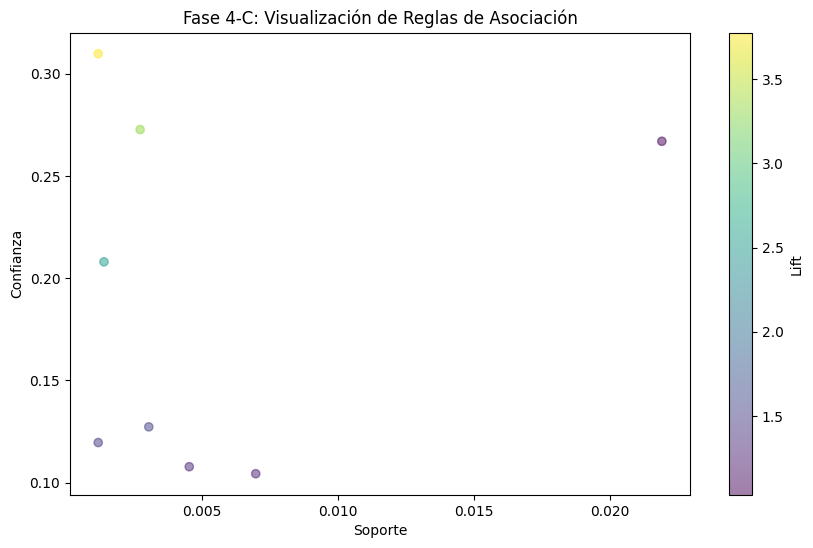

In [10]:
# ==========================================
# 7. PRUEBAS PROPIAS
# ==========================================
if not reglas.empty:
    print("--- TOP REGLAS ENCONTRADAS ---")
    print(reglas[['antecedents', 'consequents', 'confidence', 'lift']].head())
    
    # Pruebas sugeridas
    consultar_asociacion('GameCube')
    consultar_asociacion('PlayStation')
    
    # Visualización
    plt.figure(figsize=(10, 6))
    plt.scatter(reglas['support'], reglas['confidence'], alpha=0.5, c=reglas['lift'], cmap='viridis')
    plt.colorbar(label='Lift')
    plt.title("Fase 4-C: Visualización de Reglas de Asociación")
    plt.xlabel("Soporte")
    plt.ylabel("Confianza")
    plt.show()
else:
    print("\n[!] EL MODELO NO GENERÓ REGLAS. Verifica que los datos se hayan cargado correctamente.")